# CPMC sweep: walker bond χ_w at fixed L, U

Runs from `submit_mps_sweep.sh` (`run_mps_sweep.py` → `mps_cpmc_new.py`, adaptive plan, Δτ = 0.01, half filling). All (L, U, χ_w) runs of a sweep share one folder; the first cell picks which (L, U) to plot, and the loading cell lists everything the folder holds. `results.jsonl` holds the final blocking analysis, `blocks.jsonl` every block (before trot's outlier rejection), the logs hold the truncation of the reference determinant, and `reference.jsonl` the DMRG reference energies. Runs still in progress are shown with the blocks logged so far; re-run the notebook to update them.

In [50]:
RUN = "sweep_T8"      # folder given to submit_mps_sweep.sh --out
L = 32
U = 4.0
TRIAL_CHI = 8
CHI_W = None          # None: every chi_w found for this L, U
VARIANT = None        # tag suffix such as "_NOplan_NOstart_s1234"; None if the folder holds only one

In [51]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from trot.stat_utils import reject_outliers

RUN = Path(RUN)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#8e5bd0", "#d4a20f", "#d6457a"]   # categorical slots, fixed per chi_w
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 14, "axes.labelsize": 10, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2.0,
    "lines.solid_capstyle": "round", "legend.frameon": False, "font.size": 10,
})

# run_mps_sweep.py tags: L{L}[_U{U}]_T{trial_chi}_w{chi_w}{variant}, U omitted when it is 4
TAG = re.compile(r"^L(\d+)(?:_U([^_]+))?_T(\d+)_w(\d+)(_.*)$")


def parse(tag):
    m = TAG.match(tag)
    if m is None:
        return None
    L_, U_, T_, w_, variant = m.groups()
    return int(L_), float(U_) if U_ else 4.0, int(T_), int(w_), variant


def read_jsonl(path):
    return [json.loads(line) for line in open(path)] if path.exists() else []


block_lines = read_jsonl(RUN / "blocks.jsonl")
result_lines = read_jsonl(RUN / "results.jsonl")
found = {}
for r in block_lines:
    k = parse(r["tag"])
    if k:
        found.setdefault((k[0], k[1], k[2], k[4]), set()).add(k[3])
print(f"runs in {RUN}:")
for (L_, U_, T_, variant), ws in sorted(found.items()):
    print(f"  L={L_:<4} U={U_:<5g} trial_chi={T_:<3} {variant:<20} chi_w={sorted(ws)}")
print()

SELECT = (L, float(U), TRIAL_CHI)
variants = sorted(v for (L_, U_, T_, v) in found if (L_, U_, T_) == SELECT)
if VARIANT is None:
    if len(variants) != 1:
        raise ValueError(f"set VARIANT to one of {variants}" if variants
                         else f"no runs with L={L}, U={U:g}, trial_chi={TRIAL_CHI} in {RUN}")
    VARIANT = variants[0]
if CHI_W is None:
    CHI_W = tuple(sorted(found.get((*SELECT, VARIANT), ())))
COLOR = {w: PALETTE[i % len(PALETTE)] for i, w in enumerate(CHI_W)}

FIG_DIR = RUN / "plots"
FIG_DIR.mkdir(exist_ok=True)


def save(fig, name):
    # RUN/plots/L{L}_U{U}_T{trial_chi}{variant}_{name}.png, one file per figure
    path = FIG_DIR / f"L{L}_U{float(U):g}_T{TRIAL_CHI}{VARIANT}_{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")


def pick(tag):
    # chi_w of a tag from the selected (L, U, trial_chi, variant), else None
    k = parse(tag)
    return k[3] if k and k[:3] == SELECT and k[4] == VARIANT else None


results = {}
for r in result_lines:
    w = pick(r["tag"])
    if w in COLOR:
        results[w] = r
blocks = {w: [] for w in CHI_W}
for r in block_lines:
    w = pick(r["tag"])
    if w in blocks:
        blocks[w].append(r)
discarded = {}
for log in RUN.glob("*.log"):
    w = pick(log.stem)
    hit = re.search(r"discarded weights: ([0-9.e+-]+)", log.read_text()) if w in COLOR else None
    if hit:
        discarded[w] = float(hit.group(1))
runs = [w for w in CHI_W if blocks[w]]

refs = [r for r in read_jsonl(RUN / "reference.jsonl") if r["L"] == L and r["U"] == float(U)]
if refs:                                        # written by dmrg_reference.py (submit_mps_sweep.sh)
    E_ref, REF_LABEL = refs[-1]["e_variational"], f"DMRG χ={refs[-1]['chi']}"
elif float(U) == 4.0 and Path("study_dmrg_ref.jsonl").exists():   # the U=4 references of the earlier study
    E_ref = next(r["e_dmrg_chi200"] for r in read_jsonl(Path("study_dmrg_ref.jsonl")) if r["L"] == L)
    REF_LABEL = "DMRG χ=200"
else:
    E_ref, REF_LABEL = float("nan"), "no reference"
    print(f"no DMRG reference for L={L}, U={U:g} yet in {RUN / 'reference.jsonl'}")

any_result = next(iter(results.values()), None)
E_trial = any_result["trial_energy"] if any_result else float("nan")
if any_result:
    n_eql, n_total = any_result["n_equilibration"], any_result["n_equilibration"] + any_result["n_blocks"]
    n_steps, n_walkers, dt = any_result["n_steps"], any_result["n_walkers"], any_result["dt"]
else:                                           # nothing finished yet: read what the block log shows
    n_eql = next((sum(r["phase"] == "equilibration" for r in blocks[w]) for w in runs
                  if any(r["phase"] == "sampling" for r in blocks[w])), 60)
    n_total = n_steps = n_walkers = dt = None
n_max = n_total or max((len(blocks[w]) for w in runs), default=1)
xlo, xhi = min(CHI_W) - 0.5, max(CHI_W) + 1.6  # chi_w axes, room for the labels


def status(w):
    rs = blocks[w]
    if w in results and np.isfinite(results[w]["cpmc_energy"] or np.nan):
        return "done"
    dead = [r["block"] for r in rs if r["weight"] == 0 or not np.isfinite(r["energy"])]
    if dead:
        return f"population collapsed at block {dead[0]}"
    if w in results:
        return "done, no finite result"
    return f"running ({len(rs)}/{n_total} blocks)" if n_total else f"running ({len(rs)} blocks)"


def alive(w):
    # blocks before a population collapse (weight 0 or non-finite energy)
    out = []
    for r in blocks[w]:
        if r["weight"] == 0 or not np.isfinite(r["energy"]):
            break
        out.append(r)
    return out


print(f"L={L}, U={U:g}, trial_chi={TRIAL_CHI}, {VARIANT}")
print(f"{'chi_w':>5} {'discarded/channel':>18} {'E_CPMC':>12} {'error':>8} {'E - E_ref':>10} {'nodes':>8}  status")
for w in runs:
    r = results.get(w)
    E = (r["cpmc_energy"] if r else None) or float("nan")
    err = (r["cpmc_error"] if r else None) or float("nan")
    print(f"{w:>5} {discarded.get(w, float('nan')):18.2e} {E:12.5f} {err:8.5f} {E - E_ref:10.5f} "
          f"{blocks[w][-1]['node_encounters']:>8}  {status(w)}")
print(f"{REF_LABEL} reference {E_ref:.5f};  trial (chi_T={TRIAL_CHI}) {E_trial:.5f}")

runs in sweep_T8:
  L=32   U=4     trial_chi=8   _NOplan_NOstart_s1234 chi_w=[2, 4, 6]
  L=32   U=8     trial_chi=8   _NOplan_NOstart_s1234 chi_w=[2, 4, 6]
  L=32   U=12    trial_chi=8   _NOplan_NOstart_s1234 chi_w=[2, 4, 6]
  L=48   U=4     trial_chi=8   _NOplan_NOstart_s1234 chi_w=[2, 4, 6]
  L=48   U=8     trial_chi=8   _NOplan_NOstart_s1234 chi_w=[2, 4, 6]
  L=48   U=12    trial_chi=8   _NOplan_NOstart_s1234 chi_w=[2, 4, 6]

L=32, U=4, trial_chi=8, _NOplan_NOstart_s1234
chi_w  discarded/channel       E_CPMC    error  E - E_ref    nodes  status
    2           2.06e-01    -17.90362  0.00110    0.09096        8  done
    4           2.67e-04    -17.96021  0.00161    0.03437        0  done
    6           1.31e-05    -17.97795  0.00253    0.01663        0  done
DMRG χ=200 reference -17.99458;  trial (chi_T=8) -17.84773


## Energy, truncation and constraint against χ_w

One point per finished run, with the error bar from trot's blocking analysis; the dashed line in the energy plot is the trial energy alone. Runs without a finite result (a collapsed population, or still running) are left out of the energy plot but kept in the other two.

saved sweep_T8/plots/L32_U4_T8_NOplan_NOstart_s1234_energy.png


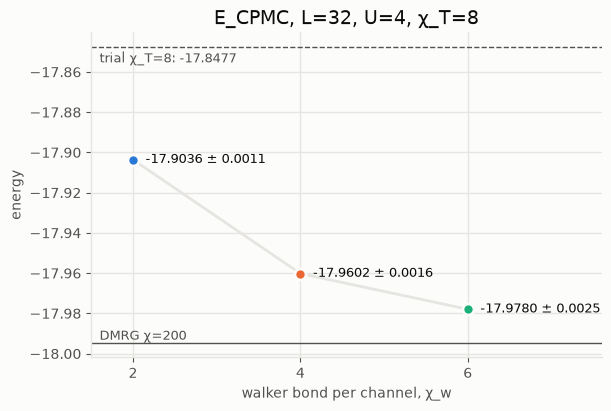

saved sweep_T8/plots/L32_U4_T8_NOplan_NOstart_s1234_discarded.png


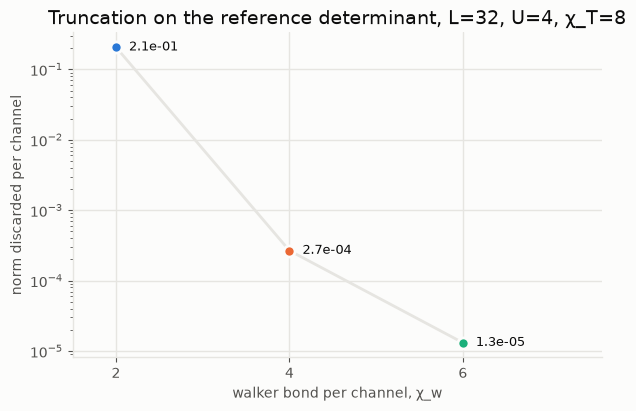

saved sweep_T8/plots/L32_U4_T8_NOplan_NOstart_s1234_node_encounters.png


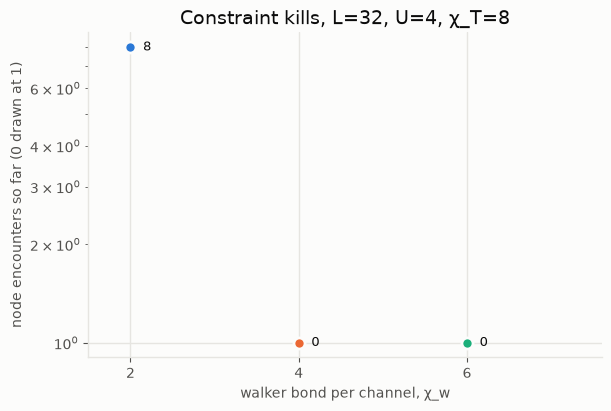

In [52]:
case = f"L={L}, U={U:g}, χ_T={TRIAL_CHI}"
done = [w for w in runs if status(w) == "done"]

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
if np.isfinite(E_ref):
    ax.axhline(E_ref, color=INK2, lw=1)
    ax.text(xlo + 0.1, E_ref, REF_LABEL, color=INK2, va="bottom", fontsize=9)
if np.isfinite(E_trial):
    ax.axhline(E_trial, color=INK2, lw=1, ls="--")
    ax.annotate(f"trial χ_T={TRIAL_CHI}: {E_trial:.4f}", xy=(xlo + 0.1, E_trial), xytext=(0, -3),
                textcoords="offset points", color=INK2, va="top", fontsize=9)
if len(done) > 1:
    ax.plot(done, [results[w]["cpmc_energy"] for w in done], color=GRID, lw=2, zorder=1)
for w in done:
    e, s = results[w]["cpmc_energy"], results[w]["cpmc_error"]
    ax.errorbar(w, e, yerr=s, fmt="o", ms=8, color=COLOR[w], mec=SURFACE, mew=2, elinewidth=2, capsize=0, zorder=3)
    ax.text(w + 0.15, e, f"{e:.4f} ± {s:.4f}", color=INK, va="center", fontsize=9)
ax.set_xlim(xlo, xhi); ax.set_xticks(CHI_W)
ax.set_xlabel("walker bond per channel, χ_w"); ax.set_ylabel("energy")
ax.set_title(f"E_CPMC, {case}")
save(fig, "energy")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ws = [w for w in runs if w in discarded]
ax.plot(ws, [discarded[w] for w in ws], color=GRID, lw=2, zorder=1)
for w in ws:
    ax.plot(w, discarded[w], "o", ms=8, color=COLOR[w], mec=SURFACE, mew=2, zorder=3)
    ax.text(w + 0.15, discarded[w], f"{discarded[w]:.1e}", color=INK, va="center", fontsize=9)
ax.set_yscale("log"); ax.set_xlim(xlo, xhi); ax.set_xticks(CHI_W)
ax.set_xlabel("walker bond per channel, χ_w"); ax.set_ylabel("norm discarded per channel")
ax.set_title(f"Truncation on the reference determinant, {case}")
save(fig, "discarded")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
for w in runs:
    n = blocks[w][-1]["node_encounters"]
    ax.plot(w, max(n, 1), "o", ms=8, color=COLOR[w], mec=SURFACE, mew=2, zorder=3)
    ax.text(w + 0.15, max(n, 1), f"{n:,}", color=INK, va="center", fontsize=9)
ax.set_yscale("log"); ax.set_xlim(xlo, xhi); ax.set_xticks(CHI_W)
ax.set_xlabel("walker bond per channel, χ_w"); ax.set_ylabel("node encounters so far (0 drawn at 1)")
ax.set_title(f"Constraint kills, {case}")
save(fig, "node_encounters")
plt.show()

## Block energies through the run

All runs in one plot: for each χ_w the thin line is the energy of every block and the thick line the running weighted mean over the sampling blocks that trot's outlier filter keeps (so it ends at the reported value). The y-range is set by the bulk of the data plus the reference and trial energies; blocks outside it are clipped. A collapsed population is drawn up to the collapse only.

saved sweep_T8/plots/L32_U4_T8_NOplan_NOstart_s1234_block_energies.png


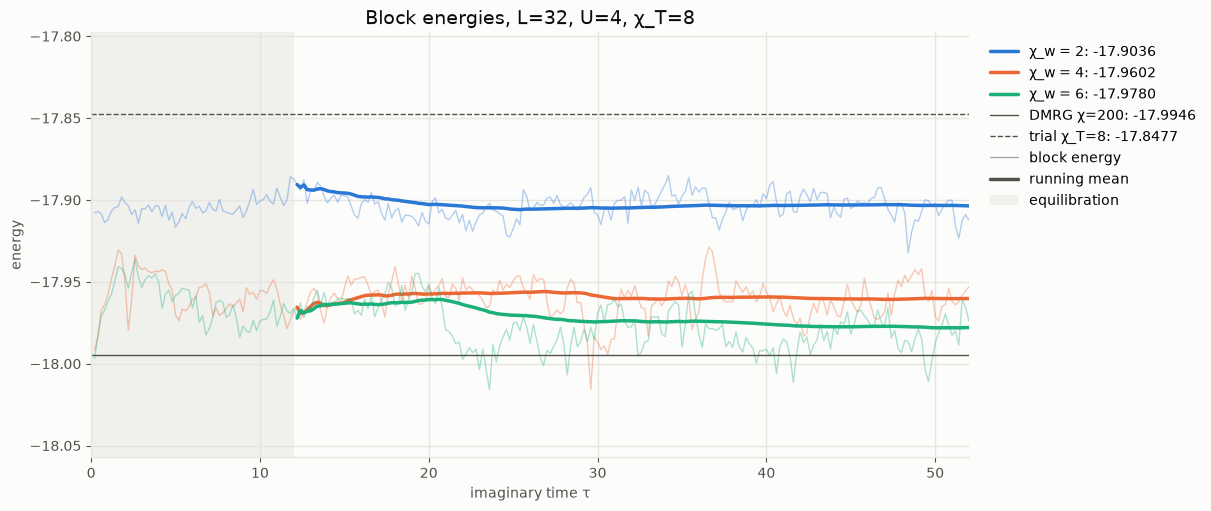

In [53]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
bulk = np.concatenate([[r["energy"] for r in alive(w)] for w in runs])
ylo, yhi = np.percentile(bulk, 0.5) - 0.05, np.percentile(bulk, 99.5) + 0.05
if np.isfinite(E_ref):
    ylo, yhi = min(ylo, E_ref - 0.05), max(yhi, E_ref + 0.05)
if np.isfinite(E_trial):
    ylo, yhi = min(ylo, E_trial - 0.05), max(yhi, E_trial + 0.05)
tau_block = n_steps * dt if n_steps and dt else None   # imaginary time per block; None: plot against block index
to_x = (lambda blk: (blk + 1) * tau_block) if tau_block else (lambda blk: blk)   # time at the end of each block
ax.axvspan(0, n_eql * tau_block if tau_block else n_eql - 0.5, color=GRID, alpha=0.5, lw=0)
handles = []
for w in runs:
    rs = alive(w)
    b = np.array([r["block"] for r in rs]); e = np.array([r["energy"] for r in rs]); wt = np.array([r["weight"] for r in rs])
    ax.plot(to_x(b), np.clip(e, ylo, yhi), color=COLOR[w], lw=1, alpha=0.35)
    s = b >= n_eql
    label = f"χ_w = {w}"
    if s.sum() > 1:
        _, keep = reject_outliers(np.column_stack((e[s], wt[s])), obs=0)
        keep = np.asarray(keep)
        bs, es, wsum = b[s][keep], e[s][keep], wt[s][keep]
        running = np.cumsum(es * wsum) / np.cumsum(wsum)
        ax.plot(to_x(bs), running, color=COLOR[w], lw=2.5)
        label += f": {running[-1]:.4f}"
    note = status(w)
    if note != "done":
        label += f" ({note})"
    handles.append(Line2D([], [], color=COLOR[w], lw=2.5, label=label))
if np.isfinite(E_ref):
    ax.axhline(E_ref, color=INK2, lw=1)
    handles.append(Line2D([], [], color=INK2, lw=1, label=f"{REF_LABEL}: {E_ref:.4f}"))
if np.isfinite(E_trial):
    ax.axhline(E_trial, color=INK2, lw=1, ls="--")
    handles.append(Line2D([], [], color=INK2, lw=1, ls="--", label=f"trial χ_T={TRIAL_CHI}: {E_trial:.4f}"))
handles += [Line2D([], [], color=INK2, lw=1, alpha=0.5, label="block energy "),
            Line2D([], [], color=INK2, lw=2.5, label="running mean"),
            Patch(color=GRID, alpha=0.5, lw=0, label="equilibration")]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_xlabel("imaginary time τ" if tau_block else "block"); ax.set_ylabel("energy")
ax.set_ylim(ylo, yhi); ax.set_xlim(0, to_x(n_max - 1))
ax.set_title(f"Block energies, L={L}, U={U:g}, χ_T={TRIAL_CHI}")
save(fig, "block_energies")
plt.show()

## Is the error bar trustworthy? Blocking curve

The sampling blocks are grouped into bins of B consecutive blocks, and the standard error of the weighted mean is recomputed from the bin means. When the blocks are effectively independent at some bin size, the curve reaches a plateau and the error bar can be trusted. A curve that keeps rising means the correlation time is comparable to the run length, and the quoted error is an underestimate.

saved sweep_T8/plots/L32_U4_T8_NOplan_NOstart_s1234_blocking_curve.png


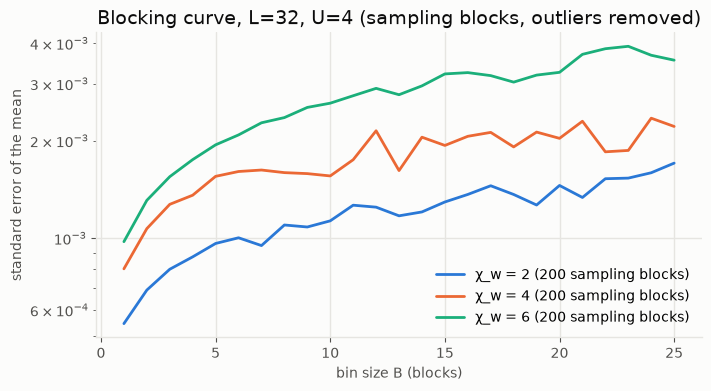

In [54]:
fig, ax = plt.subplots(figsize=(7, 3.8), constrained_layout=True)
for w in runs:
    rs = [r for r in alive(w) if r["block"] >= n_eql]
    if len(rs) < 20:
        continue
    e = np.array([r["energy"] for r in rs]); wt = np.array([r["weight"] for r in rs])
    _, keep = reject_outliers(np.column_stack((e, wt)), obs=0)
    e, wt = e[np.asarray(keep)], wt[np.asarray(keep)]
    sizes = [B for B in range(1, len(e) // 8 + 1)]
    se = []
    for B in sizes:
        k = len(e) // B
        means = [np.sum(e[i * B:(i + 1) * B] * wt[i * B:(i + 1) * B]) / np.sum(wt[i * B:(i + 1) * B]) for i in range(k)]
        se.append(np.std(means, ddof=1) / np.sqrt(k))
    ax.plot(sizes, se, color=COLOR[w], lw=2, label=f"χ_w = {w} ({len(e)} sampling blocks)")
ax.set_yscale("log")
ax.set_xlabel("bin size B (blocks)"); ax.set_ylabel("standard error of the mean")
ax.set_title(f"Blocking curve, L={L}, U={U:g} (sampling blocks, outliers removed)")
ax.legend(loc="lower right")
save(fig, "blocking_curve")
plt.show()

## Population health

Total walker weight per block (left) and cumulative node encounters (right, log scale).

saved sweep_T8/plots/L32_U4_T8_NOplan_NOstart_s1234_population.png


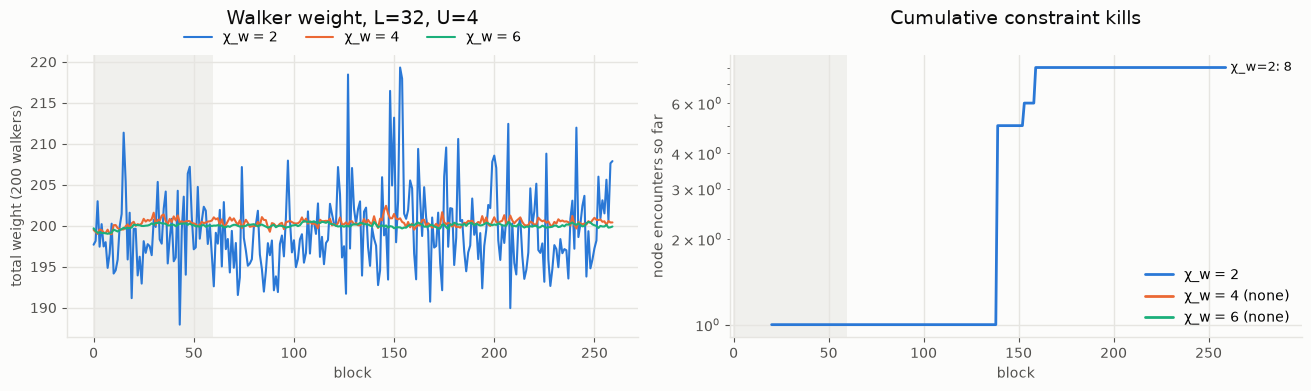

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), constrained_layout=True)
for w in runs:
    rs = blocks[w]
    b = np.array([r["block"] for r in rs])
    axes[0].plot(b, [r["weight"] for r in rs], color=COLOR[w], lw=1.5, label=f"χ_w = {w}")
    n = np.array([r["node_encounters"] for r in rs], float)
    if n[-1] > 0:
        axes[1].plot(b, np.where(n > 0, n, np.nan), color=COLOR[w], lw=2, label=f"χ_w = {w}")
        axes[1].text(b[-1] + 0.01 * n_max, n[-1], f"χ_w={w}: {int(n[-1]):,}", color=INK, va="center", fontsize=9)
    else:
        axes[1].plot([], [], color=COLOR[w], lw=2, label=f"χ_w = {w} (none)")
for ax in axes:
    ax.axvspan(-0.5, n_eql - 0.5, color=GRID, alpha=0.5, lw=0)
    ax.set_xlabel("block")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.13), ncol=min(len(runs), 6))
axes[1].legend(loc="lower right")
axes[0].set_ylabel(f"total weight ({n_walkers} walkers)" if n_walkers else "total weight")
axes[0].set_title(f"Walker weight, L={L}, U={U:g}", pad=22)
axes[1].set_yscale("log"); axes[1].set_xlim(-2, 1.15 * n_max)
axes[1].set_ylabel("node encounters so far"); axes[1].set_title("Cumulative constraint kills", pad=22)
save(fig, "population")
plt.show()

## Relative error against U, per system size

Every finished run in the folder with the selected trial bond χ_T and variant, whatever L and U the first cell picks. The relative error is (E_CPMC − E_DMRG) / |E_DMRG|, with the error bar from trot's blocking analysis scaled the same way. The dashed line is the trial energy alone.

saved sweep_T8/plots/L32_T8_NOplan_NOstart_s1234_relative_error_vs_U.png


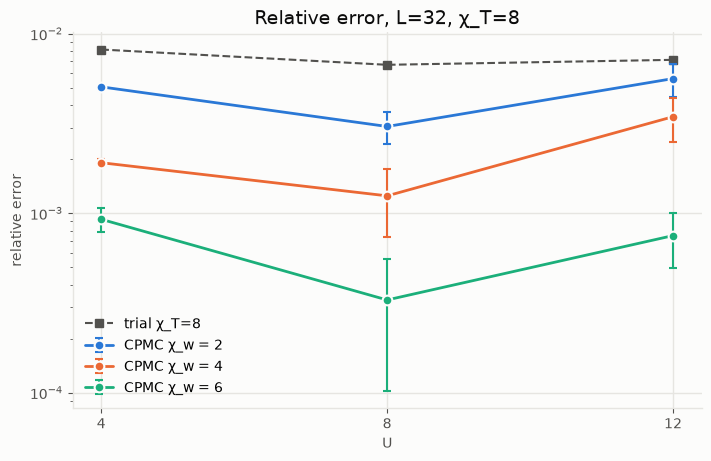

saved sweep_T8/plots/L48_T8_NOplan_NOstart_s1234_relative_error_vs_U.png


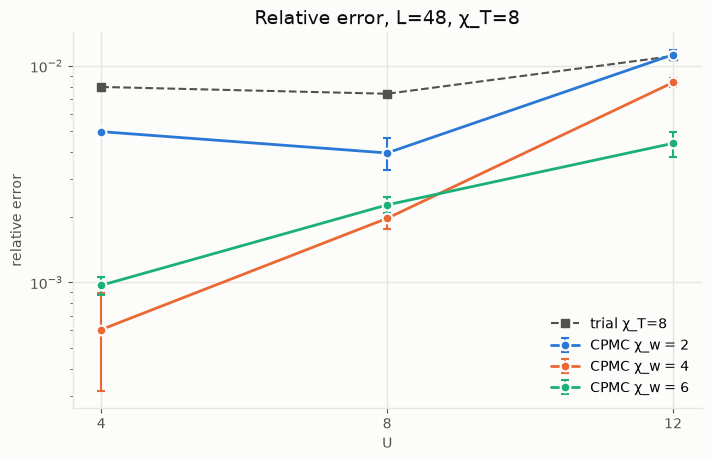

In [58]:
def reference_energy(L_, U_):
    refs = [r for r in read_jsonl(RUN / "reference.jsonl") if r["L"] == L_ and r["U"] == U_]
    if refs:
        return refs[-1]["e_variational"]
    if U_ == 4.0 and Path("study_dmrg_ref.jsonl").exists():
        return next((r["e_dmrg_chi200"] for r in read_jsonl(Path("study_dmrg_ref.jsonl")) if r["L"] == L_), np.nan)
    return np.nan


table = {}                                      # (L, U, chi_w) -> result
for r in result_lines:
    k = parse(r["tag"])
    if k and k[2] == TRIAL_CHI and k[4] == VARIANT and np.isfinite(r["cpmc_energy"] or np.nan):
        table[(k[0], k[1], k[3])] = r
all_w = sorted({w for (_, _, w) in table})
color_w = {w: PALETTE[i % len(PALETTE)] for i, w in enumerate(all_w)}

for L_ in sorted({l for (l, _, _) in table}):
    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    Us = sorted({u for (l, u, _) in table if l == L_})
    E_refs = {u: reference_energy(L_, u) for u in Us}
    trial = [(u, (table[k]["trial_energy"] - E_refs[u]) / abs(E_refs[u]))
             for u in Us for k in [next(k for k in table if k[:2] == (L_, u))]]
    ax.plot(*zip(*trial), color=INK2, lw=1.5, ls="--", marker="s", ms=6, label=f"trial χ_T={TRIAL_CHI}")
    rel_all = [t for _, t in trial]
    for w in all_w:
        pts = [(u, table[(L_, u, w)]) for u in Us if (L_, u, w) in table and np.isfinite(E_refs[u])]
        if not pts:
            continue
        u_ = np.array([u for u, _ in pts])
        rel = np.array([(r["cpmc_energy"] - E_refs[u]) / abs(E_refs[u]) for u, r in pts])
        err = np.array([r["cpmc_error"] / abs(E_refs[u]) for u, r in pts])
        ax.errorbar(u_, rel, yerr=err, color=color_w[w], lw=2, marker="o", ms=7, mec=SURFACE, mew=1.5,
                    elinewidth=1.5, capsize=3, label=f"CPMC χ_w = {w}")
        rel_all += list(rel - err)
    if min(rel_all) > 0:
        ax.set_yscale("log")
    else:
        ax.axhline(0, color=INK2, lw=1)
    ax.set_xticks(Us)
    ax.set_xlabel("U"); 
    ax.set_ylabel("relative error")
    ax.set_title(f"Relative error, L={L_}, χ_T={TRIAL_CHI}")
    ax.legend()
    path = FIG_DIR / f"L{L_}_T{TRIAL_CHI}{VARIANT}_relative_error_vs_U.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")
    plt.show()